In [ ]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(cowplot)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(msigdbr)
library(tidyverse)
library(ggpubr)
library(rstatix)
library(ggprism)
library(reshape2)
library(Seurat)
library(ggplot2)
library(cowplot)
library(tidyverse)
library(dplyr)
library(Seurat)
library(ggplot2)
library(patchwork)
library(ggsci)
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)
library(scCustomize)
library(ggplot2)
library(ggforce)
library(dplyr)
library(ggrepel)
library(patchwork)
library(ggpubr)
library(export)
library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)
library(factoextra)  
library(corrplot)   
library(pheatmap)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)  
library(GSEABase)    
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)####忽略警告

In [3]:
sp <- readRDS("./st_merge_fn2.RDS")####chip1

In [4]:
sc <- subset(sp,subset=nCount_RNA>500)
dim(sc@meta.data)

[1] 10628    35

In [5]:
table(sc@meta.data$celltype)
Idents(sc) <- as.factor(sc@meta.data$celltype)


                AC                CBC                CEC               Cone 
              1446                639                997                 44 
              Conj                CSK                 DC         Fibroblast 
               222                668                 50                 73 
                HC                LEC                LSC         Lymphocyte 
               221               1232                 23                  4 
         Macroglia         Melanocyte          Microglia            Myeloid 
               951                 37                244                 15 
        Neutrophil               NPCE    Oligodendrocyte                PCE 
                 6                 98                345                 89 
Proliferation cell                RBC                RGC           RGC axon 
                76                369               1280                 11 
               Rod                RPE       Schwann cell                SMC

In [6]:
library(monocle3) 
library(ggplot2) 
library(patchwork)
library(monocle)
library(Seurat)


Attaching package: ‘monocle3’


The following object is masked from ‘package:igraph’:

    clusters


The following objects are masked from ‘package:monocle’:

    plot_genes_in_pseudotime, plot_genes_violin,
    plot_pc_variance_explained


The following objects are masked from ‘package:Biobase’:

    exprs, fData, fData<-, pData, pData<-




In [7]:
sce.obj <- sc

In [8]:
data <- GetAssayData(sce.obj, slot = "counts")

In [9]:
# 准备phenoData，描述细胞的各种元属性，相当于seurat_obj@meta.data，行-细胞，列-属性  
pd <- new('AnnotatedDataFrame', data = sce.obj@meta.data)
# 准备featureData，基因名，行-基因名
fData <- data.frame(gene_short_name = row.names(data), 
                    row.names = row.names(data))
fd <- new('AnnotatedDataFrame', data = fData)
# 创建monocle2的celldataset(缩写为cds)对象
mycds <- newCellDataSet(data,
                        phenoData = pd,
                        featureData = fd,
                        expressionFamily = negbinomial.size())

mycds <- estimateSizeFactors(mycds)
mycds <- estimateDispersions(mycds)

Removing 496 outliers



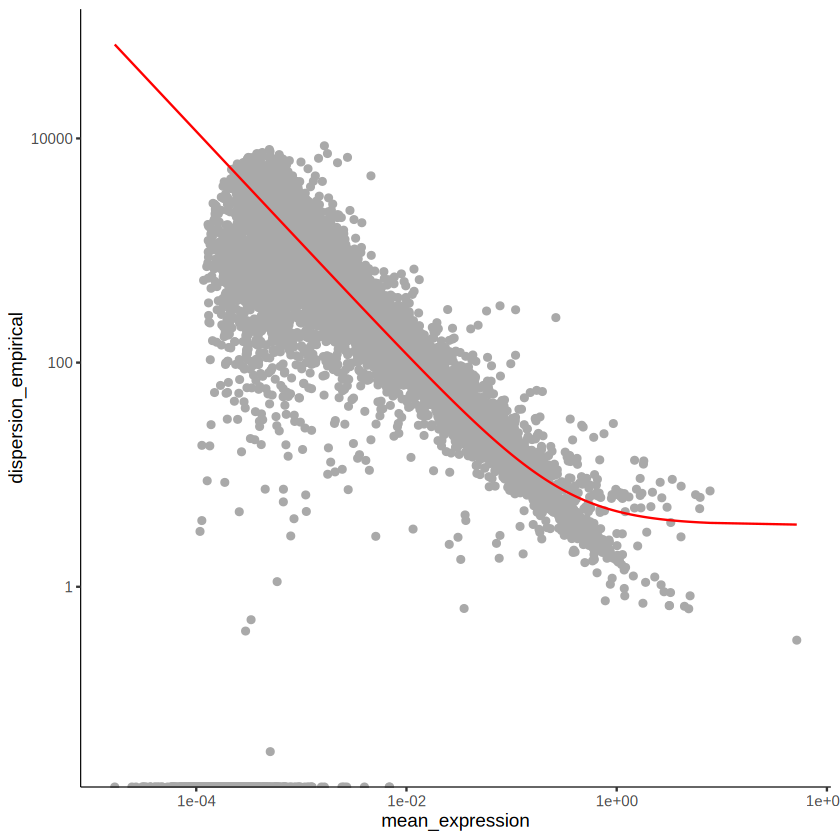

In [10]:
plot_ordering_genes(mycds)

In [11]:
mycds <- reduceDimension(mycds, max_components = 2,
                            method = 'DDRTree')

In [ ]:
mycds <- orderCells(mycds)

In [ ]:
cds <- mycds

In [ ]:
deg <- FindAllMarkers(sce.obj)

In [ ]:
gene <- unique(deg[which(deg$avg_log2FC>1&deg$p_val_adj<0.05&deg$`pct.1`>0.1),]$gene)
length(gene)

In [ ]:
cds <- setOrderingFilter(cds, gene)
plot_ordering_genes(cds)
cds <- reduceDimension(cds, max_components = 2,
                            method = 'DDRTree')

In [17]:
cds <- orderCells(cds)

In [18]:
allcolour <- c("#DC143C","#20B2AA","#FFA500","#9370DB",
               "#D2691E","#87CEEB","#FF1493","#0000CD",
               "#008B8B","#FFE4B5","#8A2BE2","#228B22","#E9967A","#4682B4",
               "#32CD32","#F0E68C","#FFFFE0","#EE82EE","#FF6347","#6A5ACD",
               "#9932CC","#8B008B","#8B4513","#DEB887",
               "#B8DBB3","#72B063","#719AAC","#E29135","#94C6CD","#4A5F7E","#A5AEB7","#925EB0",
               "#7E99F4","#CC7C71","#7AB656","#8D2F25","#4E1945","#CB9475","#8CBF87","#3E608D",
               "#909291","#B7B7EB","#9D9EA3","#EAB883","#9BBBE1","#F09BA0","#DDDDDD","#E6B745",
               "#D0DD97","#DCA7EB","#A0D0D0","#EAE936","#B7F5DE","#D5AABE","#A7C0DF","#A51C36",
               "#7ABBDB","#84BA42","#682487","#DBB428","#D4562E","#4485C7","#6F6F6F","#547BB4",
               "#C0321A","#629C35","#DD7C4F","#6C61AF","#8074C8","#7895C1","#A8CBDF","#D6EFF4",
               "#F2FAFC","#992224","#B54764","#E3625D","#EF8B67","#F0C284","#F5EBAE","#F7FBC9",
               "#3E4F94","#3E90BF","#58B6E9","#A6C0E3","#D8D3E7","#FAF9CB","#BFDFD2","#257D8B",
               "#68BED9","#EFCE87","#EAA558","#ED8D5A","#979998","#C69287","#E79A90","#EFBC91",
               "#E4CD87","#FAE5B8","#DDDDDF","#E4A031","#D68438","#C76B60","#B55384","#7C4D77",
               "#474769","#26445E","#4C7780","#73A5A2","#F6E2C1","#F3DBC1","#B2B6C1","#D6E2E2",
               "#F0EFED","#D8B365","#5BB5AC","#DE526C","#2472A3","#A5B55D","#F4F3EE","#B02425",
               "#FAA419","#4583B6","#4DB748","#218D42","#156434","#FAA419","#4583B6","#4DB748",
               "#1F8E42","#156434","#7EA6D9","#D4E6BC","#F8F2A4","#A04646","#CFC580","#75AAB8",
               "#DCCB59","#2900F2","#AE3019","#B58C9A","#8985B7","#E8DF92","#A3C98E","#B3C4D4",
               "#807C7D","#C1565E","#DCA96A","#82AD7F","#7EA4D1","#79438E","#FDEBAA","#EDC3A5",
               "#DBE4FB","#ABD1BC","#E3BBED","#CCCC99","#BED0F9","#FCB6A5","#F1F1F1","#F0EEEF",
               "#C6CCDC","#9DACCB","#7789B7","#CBD7C3","#ACBF9F","#89AA7B","#D6D6D6","#EB6969",
               "#18BECF","#BCBD23","#7F7F7F","#004600","#78B428","#C8E63C","#FFE494","#32183C",
               "#A21A54","#E7724F","#36659E","#40B7AD","#FFC04D","#82093B","#34183E","#4D779B",
               "#C45C69","#CD3B42","#585D5E","#2B5863","#6A8078","#08306B","#08519C","#2171B5",
               "#6BAED6","#C6DBEF","#FED976","#FFFFCC","#D95319","#EDB120","#0072BD","#77AC30")

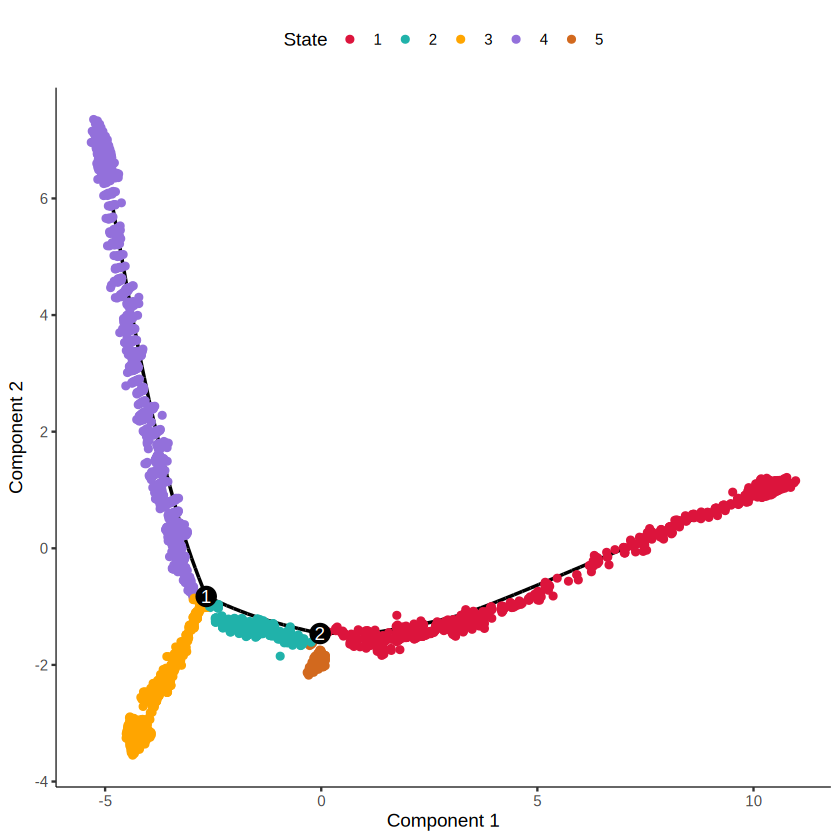

In [19]:
plot_cell_trajectory(cds)+scale_colour_manual(values = allcolour)

In [20]:
name <- "allcelltype"

In [21]:
cols <- c('Rod'="#77AC30",'Melanocyte'="#34183E",'VEC'="#238b45",'Microglia'="#ce1256",
          'Macroglia'="#DD7C4F",'Schwann cell'="#925EB0",'Oligodendrocyte'="#682487",
          'Myeloid'="#DCA7EB",'Neutrophil'="#B55384",'NPCE'="#B7F5DE",'DC'="#df65b0",
          'Lymphocyte'="#D5AABE",'Fibroblast'="#8b4a4b",'AC'="#B8DBB3",
          'CEC'="#40B7AD",'RPE'="#58B6E9",'PCE'="#D6E2E2",'Cone'="#C8E63C",
          'CBC'="#FCB6A5",'RBC'="#08306B",
          'RGC axon'="#DCCB59",'RGC'="#FAA419",
          'SMC'="#1f78b4",'Proliferation cell'="#A1CFFA",'HC'="#004600",
          'Conj'="#6C61AF",'CSK'="#D6EFF4",
          'LEC'="#72B063",'Muscle'="#A51C36",'LSC'="#8CBF87")

In [ ]:
plot_cell_trajectory(cds)+scale_colour_manual(values = allcolour)
ggsave(paste0(name,"_celltype_monocle_state_raw.pdf"),width = 6,height = 6)
plot_cell_trajectory(cds, color_by = 'celltype')+scale_colour_manual(values = cols)
ggsave(paste0(name,"_celltype_monocle_raw.pdf"),width = 6,height = 8)
plot_cell_trajectory(cds, color_by = 'Pseudotime')+scale_color_gradientn(colours = colorRampPalette(c('#5749a0', '#0f7ab0', '#00bbb1',
                                    '#bef0b0', '#fdf4af', '#f9b64b',
                                    '#ec840e', '#ca443d', '#a51a49'))(100))
ggsave(paste0(name,"_celltype_pseudotim_raw.pdf"),width = 6,height = 6)
saveRDS(cds,paste0(name,"_monocle.RDS"))

In [23]:
library(ClusterGVis)

data("HSMM")
data("BEAM_res")
data("sig_gene_names")

In [ ]:
time <- as.data.frame(DSC.cds@principal_graph_aux$UMAP$pseudotime)

In [12]:
library(Seurat)
library(monocle3)
library(monocle)
##library(monocle2)
library(ggplot2)
library(dplyr)
library("ClusterGVis")
library(jjAnno)
library(pheatmap)
library(ClusterGVis)
library(RColorBrewer)
library(stringr)
library(ClusterGVis)
library(Seurat)
library(pheatmap)
library(stringr)
library(org.Mm.eg.db)
library(cols4all)


Attaching package: ‘ClusterGVis’


The following objects are masked from ‘package:monocle3’:

    exprs, normalized_counts, pseudotime, size_factors


The following object is masked from ‘package:Biobase’:

    exprs




In [ ]:

sc <- subset(sp,subset=nCount_RNA>500)
dim(sc@meta.data)

In [ ]:
table(sc@meta.data$celltype)

In [35]:
Idents(sc) <- as.factor(sc@meta.data$celltype)
sc <- subset(x=sc,downsample=1000)

In [36]:
DSC.data <- as(as.matrix(sc@assays$RNA$data), 'sparseMatrix')

In [37]:
###meta.data
pd <- sc@meta.data
###gene symbors
fd <- data.frame(gene_short_name = row.names(DSC.data), row.names = row.names(DSC.data))
###创建monocle所需的文件类型
DSC.cds <- new_cell_data_set(DSC.data,
                             cell_metadata = pd,
                             gene_metadata = fd)

In [38]:
###Preprocess a cds to prepare for trajectory inference
DSC.cds <- preprocess_cds(DSC.cds, num_dim = 25)

In [39]:
####Align cells from different groups within a cds,细胞对齐，即为去批次效应
DSC.cds <- align_cds(DSC.cds,residual_model_formula_str = "~ sample")

In [40]:
#####降维分析
DSC.cds <- reduce_dimension(DSC.cds,preprocess_method = "PCA")

In [42]:
###降维后聚类
DSC.cds <- cluster_cells(DSC.cds,cluster_method = "louvain")

In [44]:
#####构建细胞状态转化
DSC.cds <- learn_graph(DSC.cds)

  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%


In [45]:
DSC.cds <- order_cells(DSC.cds,root_pr_nodes='Y_21')#####细胞排序

In [46]:
time <- as.data.frame(DSC.cds@principal_graph_aux$UMAP$pseudotime)

In [52]:
colnames(time) <- "pseudotime"

In [48]:
mer <- merge(sp@meta.data,time,all = TRUE,by = 0)

In [49]:
setwd("/home/ljpuser/disk1/pienapple/03eye/20others_area/monocle/")

saveRDS(mer,"monocle_time.RDS")

In [50]:
modulated_genes <- graph_test(DSC.cds, neighbor_graph = "principal_graph", cores = 4)

  |=======================================================| 100%, Elapsed 01:47


In [96]:
genes <- row.names(subset(modulated_genes, q_value == 0 & morans_I > 0.15))
length(genes)

[1] 424

In [97]:
mat <- pre_pseudotime_matrix(cds_obj = DSC.cds,
                             gene_list = genes)

# check
head(mat[1:5,1:5])

,1,2,3,4,5
2200002D01Rik,-2.6795992,-2.6785726,-2.6775461,-2.6765195,-2.6754929
2610528A11Rik,-0.6802458,-0.6792306,-0.6782155,-0.6772003,-0.6761852
4931428L18Rik,2.4604162,2.4596965,2.4589767,2.4582570,2.4575372
5830418P13Rik,2.4790653,2.4783207,2.4775761,2.4768315,2.4760868
AA467197,-1.6999928,-1.6996804,-1.6993680,-1.6990556,-1.6987432


In [98]:
class(exps)
class(mat)

[1] "data.frame"

[1] "matrix" "array"

In [99]:
ck <- clusterData(obj = as.data.frame(mat),
                  cluster.method = "kmeans",
                  cluster.num = 4)

[1] "0 genes excluded.\n"


In [85]:
Idents(sc) <- as.factor(sc@meta.data$celltype)

In [ ]:
deg <- FindAllMarkers(sc)

In [100]:
####select gene to plot 
gene <- c("Gad1","Slc32a1",##AC
          "Pde6b","Rho",##Rod
          "Pde6c","Arr3","Pde6h",##Cone
          "Nefl","Sncg","Nefm",##RGC
          "Sebox","Prkca","Gng13",###RBC
          "Scgn","Gsg1",###CBC
          "Cldn5","Mmrn2","Ptprb",###VEC
          "Lhx1","Lhx1os","Calb1",##HC
          "Slc1a3","Crym",##Macroglia
          "Lyz2","Cd68","Cd44",##Myeloid
          "H2-Ab1","H2-Eb1",##DC
          "Hcar2","S100a9","S100a8",##Neutrophil
          "C1qa","C1qb","Trem2",##Microglia
          "Hba-a1","Hba-a2",##Lymphocyte
          "Mki67","Top2a","Pclaf","Birc5",##Proliferation cell
          "Krt4","Krt19",##Conj
          "Krt12","Slurp1","Lypd2",##CEC
          "Igfbp2","Gpha2","Krt14",###LSC
          "Col17a1","Tkt",##CSK
          "Crybb3","Crybb1","Lim2",##LEC
          "Zic1","Sned1","Fbln1",##NPCE
          "Serpina3n","Spon1","Gja1",##PCE
          "Dcn","Col1a1","Col1a2",##Fibroblast
          "Acta2","Myh11","Myl9",##SMC
          "Mlana","Pmel","Dct",##Melanocyte
          "Rgr","Ttr","Rdh5",##RPE
          "Acta1","Myh4","Tnnc2",##Muscle
          "Mbp","Plp1","Mpz"###Schwann cell
         )###modulatesmc2


In [154]:
##以GO-BP为例：
enrich <- enrichCluster(object = ck,
OrgDb = org.Mm.eg.db,
type = "BP", #"BP","MF","CC" or "KEGG"
pvalueCutoff = 0.05,
topn = 10) #显示top5 GO term
head(enrich)

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



,group,Description,pvalue,ratio
,<chr>,<chr>,<dbl>,<dbl>
GO:0002088,C1,lens development in camera-type eye,5.364237e-36,25.28736
GO:0001654...2,C1,eye development,1.965897e-24,28.73563
GO:0150063,C1,visual system development,2.297615e-24,28.73563
GO:0048880,C1,sensory system development,3.292495e-24,28.73563
GO:0043010,C1,camera-type eye development,3.504642e-24,27.58621
GO:0007601...6,C1,visual perception,3.689973e-20,18.39080


In [156]:
write.csv(enrich,"cluster_gene_enrichGO.csv")

In [49]:
p <- visCluster(
    object = ck,
    plot.type = "both",add.sampleanno = F,
    column_names_rot = 45,
    show_row_dend = F,
    ctAnno.col = mycol,
    markGenes = gene)
p

In [ ]:
c('Blank2'="#2b6a99",'Blank1'="#6BAED6",'RIR1'="#FAA419",'RIR2'="#f16c23")

In [134]:
#自定义cluster注释条配色：
mycol <- c("#2b6a99","#FAA419","#f16c23","#6BAED6")

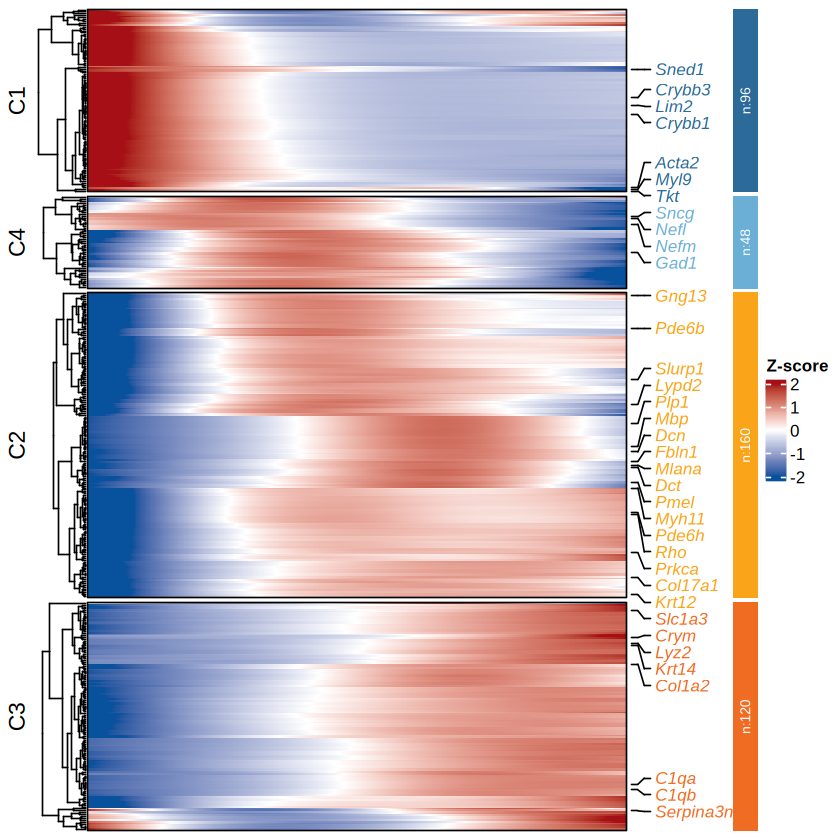

In [144]:
p <- visCluster(object = ck, plot.type = "heatmap",ctAnno.col = mycol,
           add.sampleanno = F,cluster.order=c(1,4,2,3),markGenes = gene)

In [150]:
pdf("monocle_heatmap.pdf",width = 6,height = 8)
print(p)
dev.off()

pdf 
  2

pdf 
  2

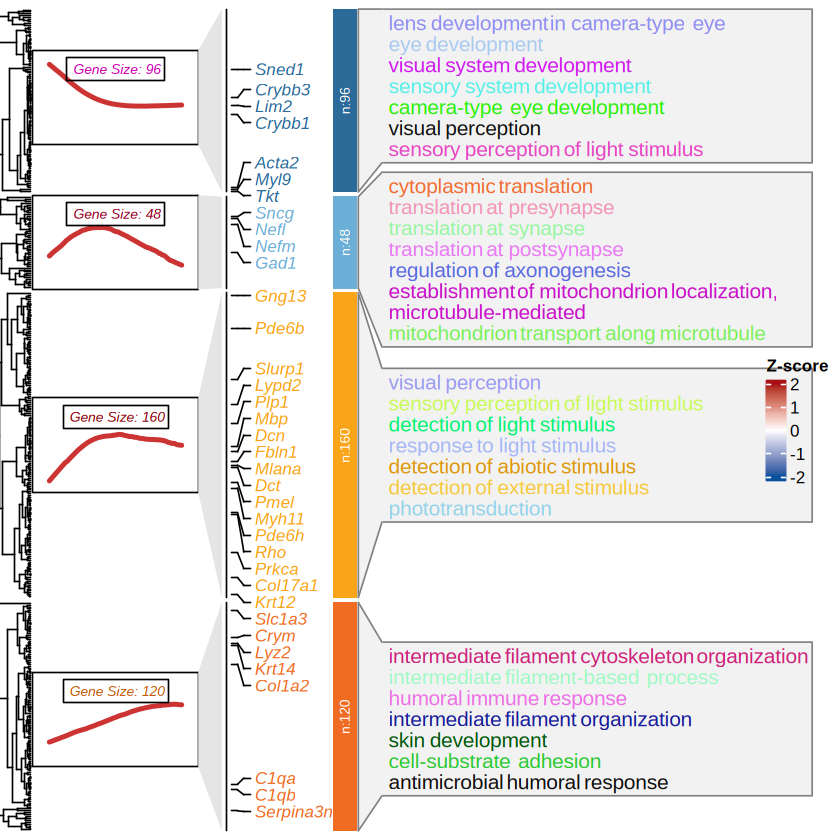

In [152]:
p <- visCluster(object = ck, plot.type = "both",ctAnno.col = mycol,line.side = "left",
           add.sampleanno = F,cluster.order=c(1,4,2,3), 
           annoTerm.data = enrich,markGenes = gene)
pdf("monocle_heatmap_enrichGO.pdf",width = 12,height = 8)
print(p)
dev.off()